# Background
We are developing a data analysis pipeline to characterise the substrate features:
1. mean diameter
2. area
3. circularity
4. tortuosity

In [ ]:
import os
import sys

sys.path.append('../../..')

import numpy as np
import matplotlib
import matplotlib.pyplot as plt

In [15]:

filepath = r'/Users/kuning/Documents/GitHub/OpenSERS-utils/substrate_BF_characterisation/test dataset/condition 1_replicate 1_result_sBFc_v1.1.npz'
arr:np.ndarray = np.load(filepath, allow_pickle=True)['arr_0']

/var/folders/fm/28xyzlz53pjg6blxlwwr9y940000gn/T/ipykernel_88413/574969862.py:2: RuntimeWarning: invalid value encountered in cast
  plt.imshow(arr.astype(np.uint8))


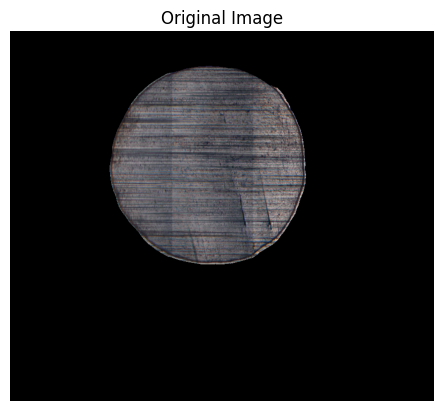

In [23]:
# Show the image stored
plt.imshow(arr.astype(np.uint8))
plt.title('Original Image')
plt.axis('off')
plt.show()

# Perimeter extraction

In [25]:
import numpy as np
from skimage import morphology

def get_boundary_pixels(arr: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """
    Extract the outermost boundary pixel coordinates of the substrate mask.
    
    Args:
        arr (np.ndarray): Masked image array (H x W x 3, float) with NaN outside substrate
    
    Returns:
        tuple[np.ndarray, np.ndarray]: (ys, xs) coordinates of boundary pixels
    """
    # Build binary mask from non-NaN pixels
    mask = ~np.isnan(arr[:, :, 0])
    
    # Erode mask by 1 pixel, boundary = mask - eroded
    eroded = morphology.erosion(mask, morphology.disk(1))
    boundary = mask & ~eroded
    
    ys, xs = np.where(boundary)
    return ys, xs

/var/folders/fm/28xyzlz53pjg6blxlwwr9y940000gn/T/ipykernel_88413/424715481.py:3: RuntimeWarning: invalid value encountered in cast
  plt.imshow(arr.astype(np.uint8))


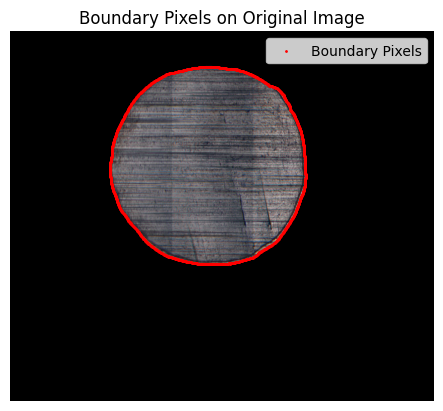

In [26]:
ys, xs = get_boundary_pixels(arr)

plt.imshow(arr.astype(np.uint8))
plt.scatter(xs, ys, s=1, c='red', label='Boundary Pixels')
plt.title('Boundary Pixels on Original Image')
plt.axis('off')
plt.legend()
plt.show()

# Characterisations

In [ ]:
from substrate_characterisation.masking.fitting import fit_ellipse_ransac, Ellipse_Cartesian, EllipseFitResult

def get_boundary_ellipse(arr: np.ndarray) -> EllipseFitResult:
    """
    Extract boundary pixels from masked image and fit a RANSAC ellipse to them.
    
    Args:
        arr (np.ndarray): Masked image array (H x W x 3, float) with NaN outside substrate
    
    Returns:
        EllipseFitResult: Fitted ellipse parameters and inliers
    """
    # Get boundary pixels
    ys, xs = get_boundary_pixels(arr)
    
    ellipse = Ellipse_Cartesian(x=xs,y=ys)
    
    # Fit ellipse using existing RANSAC function
    ellipse_fit = fit_ellipse_ransac(ellipse)
    
    return ellipse_fit

In [45]:
import json

ellipse_fit_result = get_boundary_ellipse(arr)

print("Fitted Ellipse Parameters:")
print(json.dumps({k: v for k,v in ellipse_fit_result.__dict__.items() if isinstance(v, (int, float, str))}, indent=4))

print(json.dumps({k: f'{type(v)}' for k,v in ellipse_fit_result.__dict__.items() if not isinstance(v, (int, float, str))}, indent=4))

Fitted Ellipse Parameters:
{
    "xc": 398.4970363148042,
    "yc": 268.26040455818423,
    "a": 200.00225049739186,
    "b": 196.31299759505958,
    "theta": 1.5928113852868997,
    "major_d": 400.0045009947837,
    "minor_d": 392.62599519011917,
    "circularity": 0.9998700219295236,
    "inlier_ratio": 0.9033942558746736
}
{
    "inliers": "<class 'numpy.ndarray'>",
    "model": "<class 'skimage.measure.fit.EllipseModel'>"
}


## Mean diameter

In [48]:
print(f"Mean diameter: {(ellipse_fit_result.major_d + ellipse_fit_result.minor_d)/2:.2f}")

Mean diameter: 396.32


## Area

In [52]:
def calculate_area_pixel(arr: np.ndarray) -> float:
    """
    Calculate the area of the substrate by counting non-NaN pixels.
    
    Args:
        arr (np.ndarray): Masked image array (H x W x 3, float) with NaN outside substrate
        
    Returns:
        float: Area of the substrate in pixel units
    """
    num_pixels = np.sum(~np.isnan(arr[:, :, 0]))
    return num_pixels

print(f"Area: {calculate_area_pixel(arr):.0f} pixel^2")

Area: 124582 pixel^2


## Circularity

In [53]:
def calculate_perimeter(ys:np.ndarray, xs:np.ndarray, ellipse: EllipseFitResult) -> float:
    """
    Calculate the perimeter (arc length) of the actual boundary by summing the
    Euclidean distances between consecutive boundary pixels, ordered by angle from
    the ellipse centre to ensure a continuous path along the boundary.

    Args:
        ys (np.ndarray): y-coordinates of boundary pixels
        xs (np.ndarray): x-coordinates of boundary pixels
        ellipse (EllipseFitResult): Fitted ellipse parameters with attributes xc, yc for centre coordinates

    Returns:
        float: Perimeter (arc length) of the actual boundary in pixel units
    """
    xc, yc = ellipse.xc, ellipse.yc
    angles = np.arctan2(ys - yc, xs - xc)
    sort_idx = np.argsort(angles)
    xs_sorted = xs[sort_idx]
    ys_sorted = ys[sort_idx]

    # Arc length = sum of Euclidean distances between consecutive boundary points
    # wrap around to close the loop
    dx = np.diff(np.append(xs_sorted, xs_sorted[0]))
    dy = np.diff(np.append(ys_sorted, ys_sorted[0]))
    L = np.sqrt(dx**2 + dy**2).sum()
    return L

def calculate_circularity(area_px:float, perimeter_px:float) -> float:
    """
    Calculate circularity of the substrate boundary as 4*pi*Area/Perimeter^2.
    
    Args:
        area_px (float): Area of the substrate in pixel units
        perimeter_px (float): Perimeter (arc length) of the substrate boundary in pixel units
        
    Returns:
        float: Circularity (1.0 = perfect circle, <1.0 = less circular)
    """
    if perimeter_px == 0: return 0.0  # Avoid division by zero, treat as non-circular
    circularity = 4 * np.pi * area_px / (perimeter_px ** 2)
    return circularity

print(f"Circularity: {calculate_circularity(calculate_area_pixel(arr), calculate_perimeter(ys, xs, ellipse_fit_result)):.4f}")

Circularity: 0.8763


## Tortuosity

In [ ]:
def calculate_tortuosity(ys: np.ndarray, xs: np.ndarray, ellipse: EllipseFitResult) -> float:
    """
    Calculate tortuosity of the substrate boundary as the ratio of the actual
    boundary perimeter to the fitted ellipse perimeter.
    
    τ = L / C
    where:
        L = arc length of the actual boundary (ordered boundary pixels)
        C = perimeter of the fitted RANSAC ellipse (smooth reference)
        
    Args:
        ys (np.ndarray): y-coordinates of boundary pixels
        xs (np.ndarray): x-coordinates of boundary pixels
        ellipse (EllipseFitResult): Fitted ellipse parameters
        
    Returns:
        float: tortuosity (1.0 = perfectly smooth, >1.0 = increasingly tortuous)
    """
    # --- L: actual boundary arc length ---
    # Order boundary pixels by angle from ellipse centre so we trace the 
    # boundary continuously rather than jumping around
    L = calculate_perimeter(ys, xs, ellipse)

    # --- C: fitted ellipse perimeter (Ramanujan approximation) ---
    a, b = ellipse.a, ellipse.b
    C = np.pi * (3*(a + b) - np.sqrt((3*a + b) * (a + 3*b)))

    return L / C

In [47]:
print(f"Tortuosity of the substrate boundary: {calculate_tortuosity(ys, xs, ellipse_fit_result)}")

Tortuosity of the substrate boundary: 1.0735294979975554
